In [1]:
import pandas as pd


filepath = r"C:\Users\PC 10\Downloads\onlineretail_ii.parquet"
df = pd.read_parquet(filepath)
df.columns

C:\Users\PC 10\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [2]:
df = df.rename(columns={"Customer ID": "Customer_ID"})

In [3]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer_ID', 'Country'],
      dtype='str')

In [4]:
# check missing value issue first
df.isnull().sum()



Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer_ID    243007
Country             0
dtype: int64

In [5]:
# before directly impute the description, we must check if anything else we should clean on the description
# this because we are going to try imputing the missing description using the existing similar stockcode that we have

df['Description'].value_counts(dropna=False).head(20)

Description
WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
NaN                                   4382
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
STRAWBERRY CERAMIC TRINKET BOX        2613
LUNCH BAG  BLACK SKULL.               2529
JUMBO STORAGE BAG SUKI                2434
HEART OF WICKER SMALL                 2319
JUMBO SHOPPER VINTAGE RED PAISLEY     2297
60 TEATIME FAIRY CAKE CASES           2271
PAPER CHAIN KIT 50'S CHRISTMAS        2215
LUNCH BAG SPACEBOY DESIGN             2206
REX CASH+CARRY JUMBO SHOPPER          2199
HOME BUILDING BLOCK WORD              2192
WOODEN FRAME ANTIQUE WHITE            2189
LUNCH BAG CARS BLUE                   2184
NATURAL SLATE HEART CHALKBOARD        2151
BAKING SET 9 PIECE RETROSPOT          2150
Name: count, dtype: int64

In [6]:
# result still not displaying any weird product name other than NaN
# hence we would use our domain knowledge to filter out bad regex that normally exist in product name and directly remove it

df['Description'] = df['Description'].astype(str).str.strip()
pattern = r'(?i)\b(?:check|damaged|damage|put aside|wrong|sold as|test|broken|adjust|gwp)\b'
df.loc[df['Description'].str.contains(pattern, na=False, regex=True), 'Description'] = None

df.loc[df['Description'] == "?", 'Description'] = None
df.loc[df['Description'] == "nan", 'Description'] = None



In [7]:
# then we verify check if the bad regex still exist or not

df['Description'].value_counts(dropna=True).tail(50)

Description
LARGE BLACK DIAMANTE HAIRSLIDE         1
historic computer difference?....se    1
Lighthouse Trading zero invc incorr    1
Incorrect stock entry.                 1
michel oops                            1
SET 10 CARDS 12 DAYS OF XMAS 17059     1
I LOVE LONDON MINI RUCKSACK            1
SET 36 COLOURING PENCILS DOILEY        1
SET 12 COLOURING PENCILS DOILEY        1
wrongly coded-23343                    1
WALL ART,ONLY ONE PERSON               1
crushed boxes                          1
WET/MOULDY                             1
can't find                             1
WALL ART , THE MAGIC FOREST            1
Wet pallet-thrown away                 1
Sale error                             1
ROCOCO WALL MIROR                      1
Amazon Adjustment                      1
wrongly marked 23343                   1
20713 wrongly marked                   1
re-adjustment                          1
Breakages                              1
20713                                  1
Mark

In [8]:
# since there are still a lot more bad regex, we would clean it again

df['Description'] = df['Description'].astype(str).str.strip()
pattern = r'(?i)\b(?:check|damaged|damages|damage|put aside|wrong|sold as|test|broken|adjust|gwp|wet|mouldy|crushed|error|lost|found|missing|oops|historic|incorr|breakages|rusty)\b'
df.loc[df['Description'].str.contains(pattern, na=False, regex=True), 'Description'] = None

df.loc[df['Description'] == "?", 'Description'] = None
df.loc[df['Description'] == "nan", 'Description'] = None

# then we verify check if the bad regex still exist or not

df['Description'].value_counts(dropna=True).tail(50)


Description
incorrectly put back into stock        1
MISELTOE HEART WREATH CREAM            1
Dotcomgiftshop Gift Voucher £100.00    1
SET OF 4 KNICK KNACK TINS  DOILEY      1
PINK ACRYLIC JEWEL SNOWFLAKE           1
code mix up? 84930                     1
?display?                              1
MINT DINER CLOCK                       1
ENAMEL DINNER PLATE PANTRY             1
temp adjustment                        1
PAINTED HEART WREATH WITH BELL         1
allocate stock for dotcom orders ta    1
add stock to allocate online orders    1
for online retail orders               1
website fixed                          1
FLOWER FAIRY 5 SUMMER DRAW LINERS      1
Dagamed                                1
LARGE BLACK DIAMANTE HAIRSLIDE         1
Incorrect stock entry.                 1
SET 10 CARDS 12 DAYS OF XMAS 17059     1
I LOVE LONDON MINI RUCKSACK            1
SET 36 COLOURING PENCILS DOILEY        1
SET 12 COLOURING PENCILS DOILEY        1
wrongly coded-23343                    1
WALL

In [9]:
# there is a lot more punctuation in the dataset and bad regex
# so, we will extremely remove them all until decsription is really clean


df['Description'] = df['Description'].astype(str).str.strip()
# to capture long words
pattern_aggressive = r'(?i)wrongly|allocate|online order|retail order|website|voucher|dagamed|display|adjustment|entry'
# to capture short words
pattern_safe = r'(?i)\b(?:check|damaged|damage|put aside|wrong|sold as|test|broken|adjust|gwp|wet|mouldy|crushed|error|lost|found|missing|oops|historic|incorr|breakages|rusty|samples|sample)\b'

df.loc[df['Description'].str.contains(pattern_aggressive, na=False, regex=True), 'Description'] = None
df.loc[df['Description'].str.contains(pattern_safe, na=False, regex=True), 'Description'] = None

#remove symbol/number
df.loc[df['Description'].str.contains(r'^[^a-zA-Z]*$', na=False, regex=True), 'Description'] = None

df.loc[df['Description'] == "?", 'Description'] = None
df.loc[df['Description'] == "nan", 'Description'] = None

# then we verify check if the bad regex still exist or not

df['Description'].value_counts(dropna=True).tail(50)


Description
FOOD COVER WITH BEADS , SET 2 SIZES    1
Not rcvd in 10/11/2010 delivery        1
CRYSTAL CHANDELIER T-LIGHT HOLDER      1
IVORY PANTRY HANGING LAMP              1
ZINC PLANT POT HOLDER                  1
on cargo order                         1
16 PC CUTLERY SET PANTRY DESIGN        1
ZINC STAR T-LIGHT HOLDER               1
CHRISTMAS TABLE CANDLE SILVER SPIKE    1
Printing smudges/thrown away           1
to push order througha s stock was     1
mix up with c                          1
BELL HEART ANTIQUE GOLD                1
TRAVEL CARD WALLET DOTCOMGIFTSHOP      1
ENAMEL MUG PANTRY                      1
came coded as 20713                    1
alan hodge cant mamage this section    1
FBA                                    1
BIRD ON BRANCH CANVAS SCREEN           1
DOORKNOB CERAMIC IVORY                 1
incorrectly put back into stock        1
MISELTOE HEART WREATH CREAM            1
SET OF 4 KNICK KNACK TINS  DOILEY      1
PINK ACRYLIC JEWEL SNOWFLAKE           1
code

In [10]:
#clean again because got logistic log ie on cargo order, notes

df['Description'] = df['Description'].astype(str).str.strip()

pattern_aggressive = r'(?i)wrongly|allocate|online order|retail order|website|voucher|dagamed|display|adjustment|entry|delivery|rcvd|cargo|printing|smudges|thrown|push order|mix up|coded as|incorrectly|hodge|cant|fba'
pattern_safe = r'(?i)\b(?:check|damaged|damage|put aside|wrong|sold as|test|broken|adjust|gwp|wet|mouldy|crushed|error|lost|found|missing|oops|historic|incorr|breakages|rusty|samples|sample)\b'


df.loc[df['Description'].str.contains(pattern_aggressive, na=False, regex=True), 'Description'] = None
df.loc[df['Description'].str.contains(pattern_safe, na=False, regex=True), 'Description'] = None

df.loc[df['Description'].isin(['John Lewis', 'dotcomstock', 'Marked as 23343', "can't find"]), 'Description'] = None

df.loc[df['Description'].str.contains(r'^[^a-zA-Z]*$', na=False, regex=True), 'Description'] = None
df.loc[df['Description'] == "?", 'Description'] = None
df.loc[df['Description'] == "nan", 'Description'] = None


print(df['Description'].value_counts(dropna=True).tail(50))

Description
INCENSE BAZAAR PEACH                   1
showroom                               1
Dotcom set                             1
dotcom sold sets                       1
Amazon sold sets                       1
throw away                             1
barcode problem                        1
re dotcom quick fix.                   1
Dotcom sold in 6's                     1
sold in set?                           1
cracked                                1
mystery! Only ever imported 1800       1
did  a credit  and did not tick ret    1
MARIE ANTOIENETT TRINKET BOX GOLD      1
FOOD COVER WITH BEADS , SET 2 SIZES    1
CRYSTAL CHANDELIER T-LIGHT HOLDER      1
IVORY PANTRY HANGING LAMP              1
ZINC PLANT POT HOLDER                  1
16 PC CUTLERY SET PANTRY DESIGN        1
ZINC STAR T-LIGHT HOLDER               1
CHRISTMAS TABLE CANDLE SILVER SPIKE    1
BELL HEART ANTIQUE GOLD                1
TRAVEL CARD WALLET DOTCOMGIFTSHOP      1
ENAMEL MUG PANTRY                      1
BIRD

In [11]:
#still note clean :(
#clean the product name again

df['Description'] = df['Description'].astype(str).str.strip()
pattern_aggressive = r'(?i)wrongly|allocate|online order|retail order|website|voucher|dagamed|display|adjustment|entry|delivery|rcvd|cargo|printing|smudges|thrown|push order|mix up|coded as|incorrectly|hodge|cant|fba|barcode|mystery|credit|quick fix'
pattern_safe = r'(?i)\b(?:check|damaged|damage|put aside|wrong|sold as|test|broken|adjust|gwp|wet|mouldy|crushed|error|lost|found|missing|oops|historic|incorr|breakages|rusty|samples|sample|sold|set|showroom|cracked|throw|away)\b'


df.loc[df['Description'].str.contains(pattern_aggressive, na=False, regex=True), 'Description'] = None
df.loc[df['Description'].str.contains(pattern_safe, na=False, regex=True), 'Description'] = None

df.loc[df['Description'].isin(['John Lewis', 'dotcomstock', 'Marked as 23343', "can't find"]), 'Description'] = None

df.loc[df['Description'].str.contains(r'^[^a-zA-Z]*$', na=False, regex=True), 'Description'] = None
df.loc[df['Description'] == "?", 'Description'] = None
df.loc[df['Description'] == "nan", 'Description'] = None


print(df['Description'].value_counts(dropna=True).tail(50))

Description
DRAWERKNOB ACRYLIC EDWARDIAN PURPLE    1
DRAWER KNOB ACRYLIC EDWARDIAN PINK     1
NUMBER TILE VINTAGE FONT, 1            1
NUMBER TILE VINTAGE FONT, 8            1
NUMBER TILE VINTAGE FONT, 7            1
NUMBER TILE VINTAGE FONT, 6            1
NUMBER TILE VINTAGE FONT, 5            1
NUMBER TILE VINTAGE FONT, 4            1
NUMBER TILE VINTAGE FONT, 3            1
NUMBER TILE VINTAGE FONT, 2            1
NUMBER TILE VINTAGE FONT, 0            1
ROAD-RAGE CAR FRESHENER                1
POLKADOT PENS                          1
stock take                             1
poor quality                           1
Carton qnty was 216 not 144 as stat    1
rex use                                1
ROSE PINK PENDANT SHELL NECKLACE       1
HEN PARTY BANNER TAPE                  1
IVORY PENDANT SHELL NECKLACE           1
FLOWER FAIRY MUG+COASTER,ROSE          1
mailout addition                       1
BAKING MOULD TOFFEE CUP  CHOCOLATE     1
BAKING MOULD CUPCAKE CHOCOLATE         1
amaz

In [12]:
# clean again. still x ok

df['Description'] = df['Description'].astype(str).str.strip()

pattern_aggressive = r'(?i)wrongly|allocate|online order|retail order|website|voucher|dagamed|display|adjustment|entry|delivery|rcvd|cargo|printing|smudges|thrown|push order|mix up|coded as|incorrectly|hodge|cant|fba|barcode|mystery|credit|quick fix|take|quality|carton|qnty|mailout'
pattern_safe = r'(?i)\b(?:check|damaged|damage|put aside|wrong|sold as|test|broken|adjust|gwp|wet|mouldy|crushed|error|lost|found|missing|oops|historic|incorr|breakages|rusty|samples|sample|sold|showroom|cracked|throw|away|use|sales)\b'

df.loc[df['Description'].str.contains(pattern_aggressive, na=False, regex=True), 'Description'] = None
df.loc[df['Description'].str.contains(pattern_safe, na=False, regex=True), 'Description'] = None


df.loc[df['Description'].isin(['John Lewis', 'dotcomstock', 'Marked as 23343', "can't find"]), 'Description'] = None

df.loc[df['Description'].str.contains(r'^[^a-zA-Z]*$', na=False, regex=True), 'Description'] = None
df.loc[df['Description'] == "?", 'Description'] = None
df.loc[df['Description'] == "nan", 'Description'] = None

print(df['Description'].value_counts(dropna=True).tail(50))




Description
show                                   1
MIRROR, ARCHED GEORGIAN                1
BISCUIT TIN, MINT,IVORY, VINTAGE       1
Mixed with blue                        1
DRAWER KNOB ACRYLIC EDWARDIAN CLEAR    1
DRAWER KNOB ACRYLIC EDWARDIAN GREEN    1
DRAWERKNOB ACRYLIC EDWARDIAN PURPLE    1
DRAWER KNOB ACRYLIC EDWARDIAN PINK     1
NUMBER TILE VINTAGE FONT, 1            1
NUMBER TILE VINTAGE FONT, 8            1
NUMBER TILE VINTAGE FONT, 7            1
NUMBER TILE VINTAGE FONT, 6            1
NUMBER TILE VINTAGE FONT, 5            1
NUMBER TILE VINTAGE FONT, 4            1
NUMBER TILE VINTAGE FONT, 3            1
NUMBER TILE VINTAGE FONT, 2            1
NUMBER TILE VINTAGE FONT, 0            1
ROAD-RAGE CAR FRESHENER                1
POLKADOT PENS                          1
ROSE PINK PENDANT SHELL NECKLACE       1
HEN PARTY BANNER TAPE                  1
IVORY PENDANT SHELL NECKLACE           1
FLOWER FAIRY MUG+COASTER,ROSE          1
BAKING MOULD TOFFEE CUP  CHOCOLATE     1
BAKI

In [13]:
#clean again

df['Description'] = df['Description'].astype(str).str.strip()

pattern_aggressive = r'(?i)wrongly|allocate|online order|retail order|website|voucher|dagamed|display|adjustment|entry|delivery|rcvd|cargo|printing|smudges|thrown|push order|mix up|coded as|incorrectly|hodge|cant|fba|barcode|mystery|credit|quick fix|take|quality|carton|qnty|mailout|email|sets|show|mixed|sales'
pattern_safe = r'(?i)\b(?:check|damaged|damage|put aside|wrong|sold as|test|broken|adjust|gwp|wet|mouldy|crushed|error|lost|found|missing|oops|historic|incorr|breakages|rusty|samples|sample|sold|showroom|cracked|throw|away|use)\b'


df.loc[df['Description'].str.contains(pattern_aggressive, na=False, regex=True), 'Description'] = None
df.loc[df['Description'].str.contains(pattern_safe, na=False, regex=True), 'Description'] = None

badregex = [
    'show', 'dotcom email', 'rex use', 'stock take', 'poor quality', 'debenhams',
    'Carton qnty was 216 not 144 as stat', 'mailout addition', 'amazon sales', 'missings', 'Dotcom multiple'
]
df.loc[df['Description'].isin(badregex), 'Description'] = None

df.loc[df['Description'].isin(['John Lewis', 'dotcomstock', 'Marked as 23343', "can't find"]), 'Description'] = None
df.loc[df['Description'].str.contains(r'^[^a-zA-Z]*$', na=False, regex=True), 'Description'] = None
df.loc[df['Description'] == "?", 'Description'] = None
df.loc[df['Description'] == "nan", 'Description'] = None\


print(df['Description'].value_counts(dropna=True).tail(50))


Description
LUNCH BAG PINK POLKADOTS               1
CHROME EURO HOOK 20cm                  1
MIRROR, ARCHED GEORGIAN                1
BISCUIT TIN, MINT,IVORY, VINTAGE       1
DRAWER KNOB ACRYLIC EDWARDIAN CLEAR    1
DRAWER KNOB ACRYLIC EDWARDIAN GREEN    1
DRAWERKNOB ACRYLIC EDWARDIAN PURPLE    1
DRAWER KNOB ACRYLIC EDWARDIAN PINK     1
NUMBER TILE VINTAGE FONT, 1            1
NUMBER TILE VINTAGE FONT, 8            1
NUMBER TILE VINTAGE FONT, 7            1
NUMBER TILE VINTAGE FONT, 6            1
NUMBER TILE VINTAGE FONT, 5            1
NUMBER TILE VINTAGE FONT, 4            1
NUMBER TILE VINTAGE FONT, 3            1
NUMBER TILE VINTAGE FONT, 2            1
NUMBER TILE VINTAGE FONT, 0            1
ROAD-RAGE CAR FRESHENER                1
POLKADOT PENS                          1
ROSE PINK PENDANT SHELL NECKLACE       1
HEN PARTY BANNER TAPE                  1
IVORY PENDANT SHELL NECKLACE           1
FLOWER FAIRY MUG+COASTER,ROSE          1
BAKING MOULD TOFFEE CUP  CHOCOLATE     1
BAKI

In [20]:
# now data product name already clean from missing name so, we can start impute the data

#create master lookup
master_desc = df.dropna(subset=['Description']).groupby('StockCode')['Description'].max()
desc_lookup_dict = master_desc.to_dict()

df['Description'] = df['Description'].fillna(df['StockCode'].map(desc_lookup_dict))
df['Description'] = df['Description'].fillna("NA")

print("missing value on description:", df['Description'].isnull().sum())
print("description that na:", (df['Description'] == "NA").sum())

missing value on description: 0
description that na: 106014


In [21]:
#check stockcode with most na description
df[df['Description'] == "NA"]['StockCode'].value_counts().head(20)

StockCode
21080    2224
20914    2213
22138    2154
22720    1477
22960    1315
84378    1309
22961    1303
22328    1243
21210    1203
22909    1203
84380    1162
22993    1111
84988    1045
22617    1037
21094    1012
21035     974
22561     957
21121     923
22413     922
23245     919
Name: count, dtype: int64

In [26]:




# =========================================================================
# STEP 4: SAPU BERSIH SISA SPESIFIK & SIMBOL
# =========================================================================
sisa_tegar = [
    'show', 'dotcom email', 'rex use', 'stock take', 'poor quality', 
    'Carton qnty was 216 not 144 as stat', 'mailout addition', 'amazon sales',
    'debenhams', 'missing', 'Dotcom multiple', 'John Lewis', 'dotcomstock', 
    'Marked as 23343', "can't find", '?', 'nan', '????damages????', '?display?', 'display','damages/display', 'Display' 
]
df.loc[df['Description'].isin(sisa_tegar), 'Description'] = None
df.loc[df['Description'].str.contains(r'^[^a-zA-Z]*$', na=False, regex=True), 'Description'] = None


# =========================================================================
# STEP 5: IMPUTASI MUKTAMAD (Membina semula master lookup dari data segar)
# =========================================================================
master_desc = df.dropna(subset=['Description']).groupby('StockCode')['Description'].max()
desc_lookup_dict = master_desc.to_dict()

# Isi baris kosong mengikut gandingan StockCode
df['Description'] = df['Description'].fillna(df['StockCode'].map(desc_lookup_dict))

# Baki yang BENAR-BENAR tiada nama produk langsung baru diletakkan "NA"
df['Description'] = df['Description'].fillna("NA")


# =========================================================================
# STEP 6: VERIFIKASI SELEPAS RESET
# =========================================================================
(df['Description'] == "NA").sum()

3225

In [27]:
print(df['Description'].value_counts(dropna=True).tail(50))

Description
NUMBER TILE VINTAGE FONT, 8            1
NUMBER TILE VINTAGE FONT, 7            1
NUMBER TILE VINTAGE FONT, 6            1
NUMBER TILE VINTAGE FONT, 5            1
NUMBER TILE VINTAGE FONT, 4            1
NUMBER TILE VINTAGE FONT, 3            1
NUMBER TILE VINTAGE FONT, 2            1
NUMBER TILE VINTAGE FONT, 0            1
ROSE PINK PENDANT SHELL NECKLACE       1
HEN PARTY BANNER TAPE                  1
IVORY PENDANT SHELL NECKLACE           1
BAKING MOULD TOFFEE CUP  CHOCOLATE     1
BAKING MOULD CUPCAKE CHOCOLATE         1
INCENSE BAZAAR PEACH                   1
Dotcom set                             1
MARIE ANTOIENETT TRINKET BOX GOLD      1
FOOD COVER WITH BEADS , SET 2 SIZES    1
CRYSTAL CHANDELIER T-LIGHT HOLDER      1
IVORY PANTRY HANGING LAMP              1
ZINC PLANT POT HOLDER                  1
16 PC CUTLERY SET PANTRY DESIGN        1
ZINC STAR T-LIGHT HOLDER               1
CHRISTMAS TABLE CANDLE SILVER SPIKE    1
BELL HEART ANTIQUE GOLD                1
TRAV

In [30]:
# Cipta kolum Total_Sales
df['Total_Sales'] = df['Quantity'] * df['Price']

# Semak 5 baris teratas
print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041          RECORD FRAME 7" SINGLE SIZE        48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  Total_Sales  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom         83.4  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom         81.0  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom         81.0  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom        100.8  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom         30.0  


In [34]:
import numpy as np

# Tambah kolum baru bernama 'Log_Total_Sales'
# Kita guna np.log10 untuk tukar skewness data melampau tu
#df = df.with_columns([
 #   (np.log10(df['Total_Sales'] + 1)).alias('Log_Total_Sales')
#]) # Versi Polars

# Jika guna Pandas:
df_positive_sales = df[df['Total_Sales'] > 0].copy()

# 3. Sekarang baru buat Log Transformation dengan selamat tanpa amaran error!
df_positive_sales['Log_Total_Sales'] = np.log10(df_positive_sales['Total_Sales'])


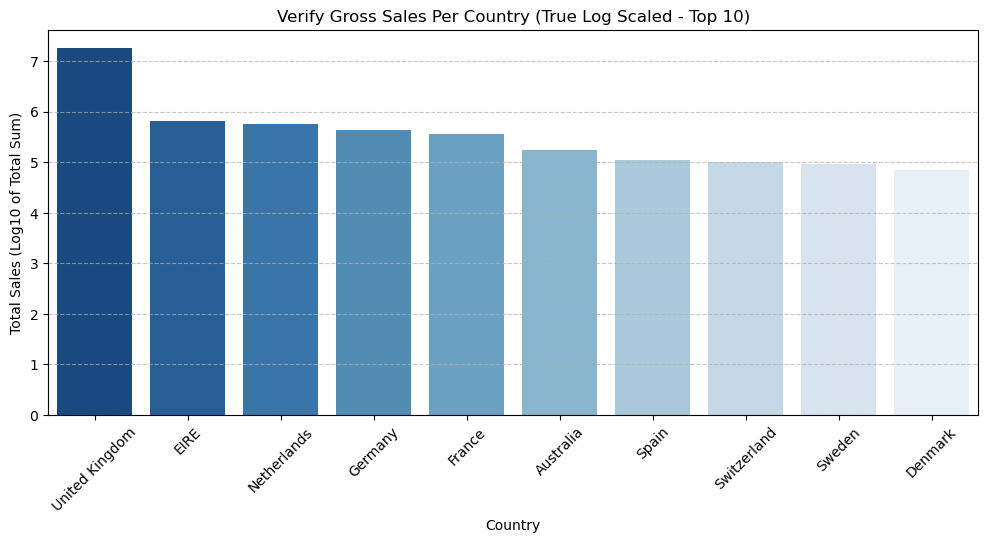

In [37]:
# 1. Ambil data Gross Sales (Jualan positif sahaja)
df_gross = df[df['Total_Sales'] > 0].copy()

# 2. GROUPBY DULU: Dapatkan jumlah jualan asal (raw sum) bagi setiap negara
country_raw_sum = df_gross.groupby('Country')['Total_Sales'].sum()

# 3. BARU LOG-KAN: Tukar hasil tambah tadi kepada skala log10
country_sales = np.log10(country_raw_sum).sort_values(ascending=False).head(10)

# 4. Plot semula (Gunakan x dan y yang betul dari siri country_sales)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
# Tukar kod mengikut amaran FutureWarning Seaborn terbaru
sns.barplot(x=country_sales.index, y=country_sales.values, hue=country_sales.index, palette="Blues_r", legend=False)
plt.title("Verify Gross Sales Per Country (True Log Scaled - Top 10)")
plt.xlabel("Country")
plt.ylabel("Total Sales (Log10 of Total Sum)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [38]:
(df_gross['Description'] == "NA").sum()

2613

In [39]:
df_gross['Total_Sales'].min()

0.001

In [43]:
print(df_gross['Description'].value_counts(dropna=True).tail(50))

Description
NUMBER TILE VINTAGE FONT, 3            1
NUMBER TILE VINTAGE FONT, 2            1
NUMBER TILE VINTAGE FONT, 0            1
ROAD-RAGE CAR FRESHENER                1
POLKADOT PENS                          1
ROSE PINK PENDANT SHELL NECKLACE       1
HEN PARTY BANNER TAPE                  1
IVORY PENDANT SHELL NECKLACE           1
FLOWER FAIRY MUG+COASTER,ROSE          1
BAKING MOULD TOFFEE CUP  CHOCOLATE     1
BAKING MOULD CUPCAKE CHOCOLATE         1
INCENSE BAZAAR PEACH                   1
MARIE ANTOIENETT TRINKET BOX GOLD      1
FOOD COVER WITH BEADS , SET 2 SIZES    1
CRYSTAL CHANDELIER T-LIGHT HOLDER      1
IVORY PANTRY HANGING LAMP              1
ZINC PLANT POT HOLDER                  1
16 PC CUTLERY SET PANTRY DESIGN        1
ZINC STAR T-LIGHT HOLDER               1
CHRISTMAS TABLE CANDLE SILVER SPIKE    1
BELL HEART ANTIQUE GOLD                1
ENAMEL MUG PANTRY                      1
BIRD ON BRANCH CANVAS SCREEN           1
BLUE MONTE CARLO HANDBAG               1
DOOR

In [41]:
# 1. Rename kolum 'Customer ID' kepada 'Customer_ID' (Buang space)
df_gross = df_gross.rename(columns={'Customer ID': 'Customer_ID'})



In [44]:
import numpy as np
import pandas as pd

# 1. Ambil data Gross Sales (Jualan positif sahaja) dlu
df_gross = df[df['Total_Sales'] > 0].copy()

# 2. Tapis sisa-sisa string log admin yang tak valid sebelum bina master lookup
invalid_descriptions = ['NA', '', 'nan', '?', '????damages????', '?display?', 'display', 'damaged', 'check']
df_desc_clean = df_gross[
    df_gross['Description'].notna() & 
    (~df_gross['Description'].astype(str).str.lower().isin(invalid_descriptions))
]

# 3. Bina Master Lookup Dictionary (Ambil nama string tertinggi .max() bagi setiap StockCode)
desc_lookup_dict = df_desc_clean.groupby('StockCode')['Description'].max().to_dict()

# 4. Guna .map() untuk 'timpa' kolum Description asal supaya semua bersatu (Unified)
# Jika StockCode tak jumpa dalam dict, kita kekalkan nama asal atau letak 'NA' guna .fillna()
df_gross['Description'] = df_gross['StockCode'].map(desc_lookup_dict).fillna(df_gross['Description']).fillna('NA')



In [45]:
# Kirim bilangan nama unik bagi setiap StockCode
check_dup = df_gross.groupby('StockCode')['Description'].nunique()

# Tapis yang ada lebih dari 1 nama
duplicated_codes = check_dup[check_dup > 1]

print(f"Jumlah StockCode yang masih ada duplicate: {len(duplicated_codes)}")

Jumlah StockCode yang masih ada duplicate: 0


In [49]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer_ID', 'Country', 'Total_Sales', 'Log_Total_Sales'],
      dtype='str')

In [48]:
df = df_gross.rename(columns={"Customer ID": "Customer_ID"})

In [50]:
df.to_parquet(filepath, index=False)

In [17]:
df_check = pd.read_parquet(filepath)

In [18]:
df_check.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer_ID', 'Country'],
      dtype='str')

In [ ]:
#chec